## **Triple-pendulum model by SREINet**


## **I. Setup and Preprocessing**

In [15]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Tensowflow version should be 2.13.0 or
# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("*******************************|***************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()


opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
*******************************|***************


### **1.2 Training Data**

In [16]:
def load_triple_pendulum_data(mat_path, downsample=1):
    """
    Loads triple pendulum data from a MATLAB .mat file and returns the relevant arrays, with optional downsampling.
    Args:
        mat_path (str): Path to the .mat file.
        downsample (int): Take every nth sample (default 1, i.e., no downsampling)
    Returns:
        my_data (np.ndarray): Concatenated array of [theta1, theta2, theta3, d_theta1, d_theta2, d_theta3], shape (N, 6)
        d_theta (np.ndarray): Concatenated array of [d_theta1, d_theta2, d_theta3], shape (N, 3)
        time (np.ndarray): Time array
        dt (float): Time step
    """
    from scipy.io import loadmat
    import numpy as np

    data = loadmat(mat_path)
    theta1 = data['Theta1'][::downsample]
    theta2 = data['Theta2'][::downsample]
    theta3 = data['Theta3'][::downsample]
    d_theta1 = data['dTheta1'][::downsample]
    d_theta2 = data['dTheta2'][::downsample]
    d_theta3 = data['dTheta3'][::downsample]

    my_data = np.concatenate([theta1, theta2, theta3, d_theta1, d_theta2, d_theta3], axis=1)
    d_theta = np.concatenate([d_theta1, d_theta2, d_theta3], axis=1)

    return my_data, d_theta

#### Create dataset

In [17]:
# Specify the model type
MY_DATA_TYPE = 'float32'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

import scipy.io as sio
import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
import cmocean

from sklearn.preprocessing import MinMaxScaler

from scipy.signal import savgol_filter


#load data
from scipy.io import loadmat

data_1, d_theta_1 = load_triple_pendulum_data('../experiment_data/TriplePendulum_Data/TripleDataFreeSwing_1_Dt_0_0001.mat',downsample=100)
data_2, d_theta_2 = load_triple_pendulum_data('../experiment_data/TriplePendulum_Data/TripleDataFreeSwing_2_Dt_0_0001.mat',downsample=100)

my_data = np.concatenate([data_1, data_2], axis=0)

dt = 0.0001 * 100 #original dt



# Calculate derivative using Savitzky-Golay filter
window_length = 7  # Window length
polyorder = 2     # Polynomial order
dd_theta_1 = savgol_filter(d_theta_1, window_length, polyorder, delta=dt, deriv=1, axis=0)
dd_theta_2 = savgol_filter(d_theta_2, window_length, polyorder, delta=dt, deriv=1, axis=0)

derivative_data_1 = np.concatenate([d_theta_1, dd_theta_1], axis=1)
derivative_data_2 = np.concatenate([d_theta_2, dd_theta_2], axis=1)
derivative_data = np.concatenate([derivative_data_1, derivative_data_2], axis=0)


In [18]:
training_input = np.concatenate([my_data], axis=1)
training_output = derivative_data


print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

Training input shape: (12002, 6)
Training output shape: (12002, 6)


### **1.3 Hyperparameters**


In [5]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [6]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guess_highest_order_polynomial = 3

layer_depth = guess_highest_order_polynomial
# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn)

[6, 6, 6]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [7]:
my_activation = [lambda x:x,
                 lambda x:tf.cos(x),
                 lambda x:tf.sin(x),
                 lambda x:tf.cos(2*x),
                 lambda x:tf.sin(2*x),
                 ]

inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 1, 
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=SEED),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)



### **2.2 Loss Function**

In [8]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [9]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [10]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

### First three dimensions

#### **Pruning Profile**

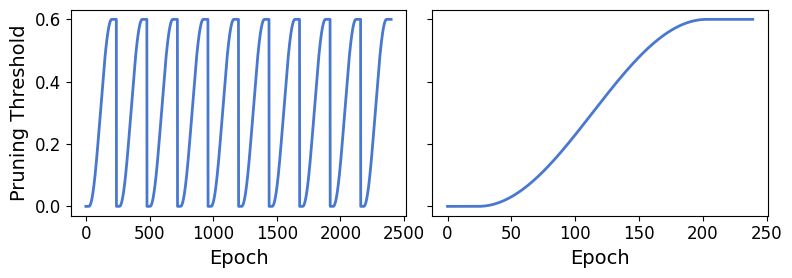

In [11]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.6 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 10
PRUNING_EPOCHS_PER_PERIOD = 240
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

# Define the pruning schedule

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.1,
                    show_plot=True)


### Training

In [12]:
#Setup
EARLY_STOPPING_LOSS_THRESHOLD = 1e-8  # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.1

training_histories = []
weights_list = []
loss_list = []


In [13]:
for i in range(0, 3):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.00,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
     print_every_n_epochs=10,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)   

Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 1.334e-01,  Validation Loss: 0.000e+00,  Epoch Time: 0.48s,  Current Pruning Threshold: 0
Epoch  11 (Period 1):  Train Loss: 8.105e-04,  Validation Loss: 0.000e+00,  Epoch Time: 0.22s,  Current Pruning Threshold: 0
Epoch  21 (Period 1):  Train Loss: 1.226e-04,  Validation Loss: 0.000e+00,  Epoch Time: 0.22s,  Current Pruning Threshold: 0
Epoch  31 (Period 1):  Train Loss: 1.240e-05,  Validation Loss: 0.000e+00,  Epoch Time: 0.22s,  Current Pruning Threshold: 0.0016618
Epoch  41 (Period 1):  Train Loss: 2.047e-04,  Validation Loss: 0.000e+00,  Epoch Time: 0.22s,  Current Pruning Threshold: 0.011751
Epoch  51 (Period 1):  Train Loss: 1.981e-05,  Validation Loss: 0.000e+00,  Epoch Time: 0.22s,  Current Pruning Threshold: 0.030696
Epoch  61 (Period 1):  Train Loss: 3.305e-04,  Validation Loss: 0.000e+00,  Epoch Time: 0.25s,  Current Pruning Threshold: 0.057915
Epoch  71 (Period 1):  Train Loss: 7.530e-06,  Validation Loss: 0.000e+0

### Last three dimensions

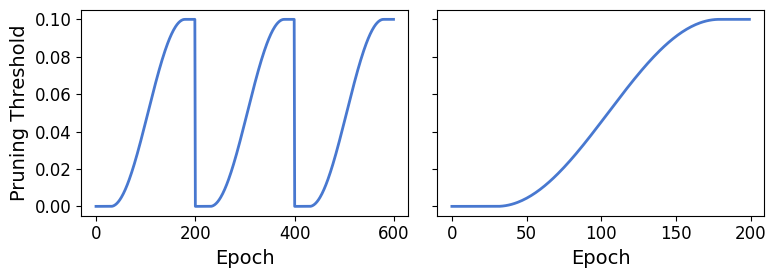

In [14]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.1 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 3
PRUNING_EPOCHS_PER_PERIOD = 200
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

# Define the pruning schedule

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)

In [15]:

EARLY_STOPPING_LOSS_THRESHOLD = 2.5e-1  # last three dimensions
EARLY_STOPPING_PRUNING_THRESHOLD = 0.02

In [16]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(3, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]

    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
     print_every_n_epochs=10,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)      

Training dimension 4...
Epoch   1 (Period 1):  Train Loss: 4.930e+01,  Validation Loss: 8.322e+00,  Epoch Time: 0.40s,  Current Pruning Threshold: 0
Epoch  11 (Period 1):  Train Loss: 3.625e+00,  Validation Loss: 3.032e+00,  Epoch Time: 0.26s,  Current Pruning Threshold: 0
Epoch  21 (Period 1):  Train Loss: 2.319e+00,  Validation Loss: 2.354e+00,  Epoch Time: 0.23s,  Current Pruning Threshold: 0
Epoch  31 (Period 1):  Train Loss: 1.831e+00,  Validation Loss: 1.700e+00,  Epoch Time: 0.23s,  Current Pruning Threshold: 0
Epoch  41 (Period 1):  Train Loss: 1.350e+00,  Validation Loss: 1.193e+00,  Epoch Time: 0.24s,  Current Pruning Threshold: 0.0011073
Epoch  51 (Period 1):  Train Loss: 9.464e-01,  Validation Loss: 7.693e-01,  Epoch Time: 0.23s,  Current Pruning Threshold: 0.0043801
Epoch  61 (Period 1):  Train Loss: 7.281e-01,  Validation Loss: 7.387e-01,  Epoch Time: 0.24s,  Current Pruning Threshold: 0.0096734
Epoch  71 (Period 1):  Train Loss: 6.163e-01,  Validation Loss: 5.729e-01,  E

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [17]:
def generate_layer_labels(N): # N is the number of neurons per layer
    num_terms = N // 5 # get the number of state variables. 

    return ['Constant'] + [f'x{i}' for i in range(1, num_terms+1)] + [f'cos(x{i})' for i in range(1, num_terms+1)] + [f'sin(x{i})' for i in range(1, num_terms+1)] + [f'cos(2*x{i})' for i in range(1, num_terms+1)] + [f'sin(2*x{i})' for i in range(1, num_terms+1)]

def generate_LHS_labels(N):
    num_terms = N // 5
    return [f"(x{i})'" for i in range(1, num_terms+1)]

#### `coefficient_reconstruction`

In [18]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [19]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 1.000000096*x4
(x2)' = 1.000001023*x5
(x3)' = 1.000000139*x6
(x4)' = 0.06462926946 + 0.1613832262*x1 + 0.09415424018*x3 - 0.07182783865*cos(x1) - 0.02296227836*cos(x4) + 0.02170257264*cos(x5) - 0.3533853332*sin(x1) + 0.7218077333*sin(x2) + 0.1208717885*sin(x3) + 0.01397313436*sin(x6) - 0.2665615967*cos(2*x1) - 0.4263462947*cos(2*x2) - 0.1737354146*cos(2*x3) + 0.3416209997*sin(2*x1) - 0.7053509064*sin(2*x2) - 0.02996046703*sin(2*x3) - 0.02847486488*sin(2*x6) - 0.154145362*cos(x1)*x1 - 0.06429919859*cos(x3)*x1 + 0.02937785669*cos(x5)*x1 - 0.4235140707*sin(x1)*x1 + 0.8898921932*sin(x2)*x1 + 0.1702499669*sin(x3)*x1 + 0.01338869322*sin(x4)*x1 + 0.01662651355*sin(x6)*x1 - 0.4084170304*cos(2*x1)*x1 - 0.553084064*cos(2*x2)*x1 - 0.1444842687*cos(2*x3)*x1 - 0.009511862691*cos(2*x5)*x1 + 0.3569770936*sin(2*x1)*x1 - 0.8714231985*sin(2*x2)*x1 - 0.03559340051*sin(2*x3)*x1 - 0.1005224499*cos(x1)*x3 + 0.004950302219*cos(x1)*x4 - 0.009975761444*cos(x1)*x5 - 0.001978269826*cos(x1)^2 - 0.09283775

### Validation

In [20]:
import importlib

import model_reconstructor as mr

importlib.reload(mr)

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str)


val_t_span = [0,10]
val_t_eval = np.arange(0,10,dt)

# x includes theta and d_theta
val_x, val_d_theta = load_triple_pendulum_data('../experiment_data/TriplePendulum_Data/TripleDataFreeSwing_3_Dt_0_0001.mat',downsample=100)

data_initial_conditions = val_x[0]
SREINet_pred = recovered_model.simulate(data_initial_conditions, t_span=val_t_span, t_eval=val_t_eval, method='RK45')

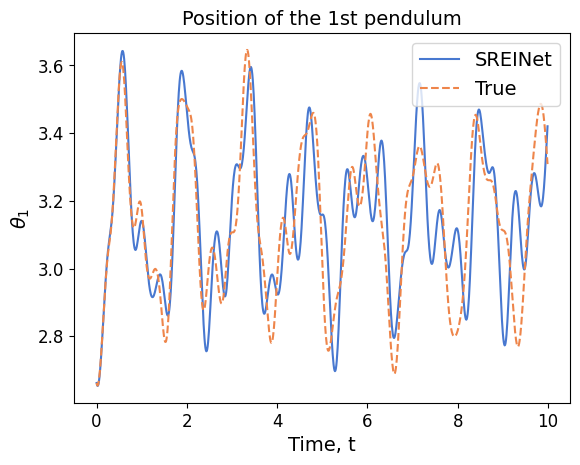

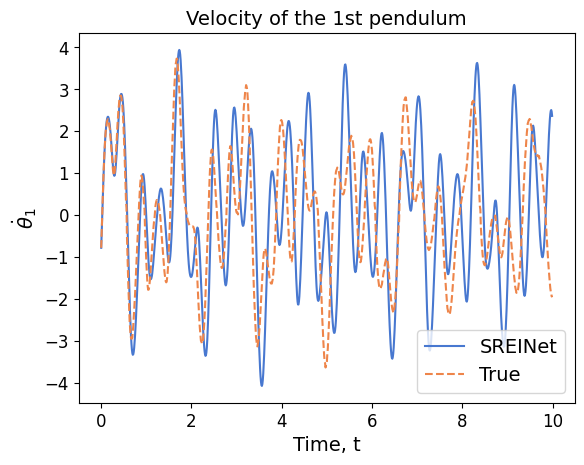

In [25]:
import matplotlib.pyplot as plt

plt.plot(SREINet_pred['t'], SREINet_pred['y'][0],label='SREINet')
plt.plot(val_t_eval, val_x[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\theta_1$')
plt.title('Position of the 1st pendulum')
plt.legend()
plt.show()

plt.figure()
plt.plot(SREINet_pred['t'], SREINet_pred['y'][3],label='SREINet')
plt.plot(val_t_eval, val_x[:val_t_eval.shape[0],3], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\dot{\theta}_1$')
plt.title('Velocity of the 1st pendulum')
plt.legend()
plt.show()

In [22]:
#calculate derivatives 
pred_dx = recovered_model.predict_derivatives(SREINet_pred['y'].transpose())
pred_dx = pred_dx.transpose()

# Calculate derivative using Savitzky-Golay filter
window_length = 7  # Window length
polyorder = 2     # Polynomial order
val_dd_theta = savgol_filter(val_d_theta, window_length, polyorder, delta=dt, deriv=1, axis=0)

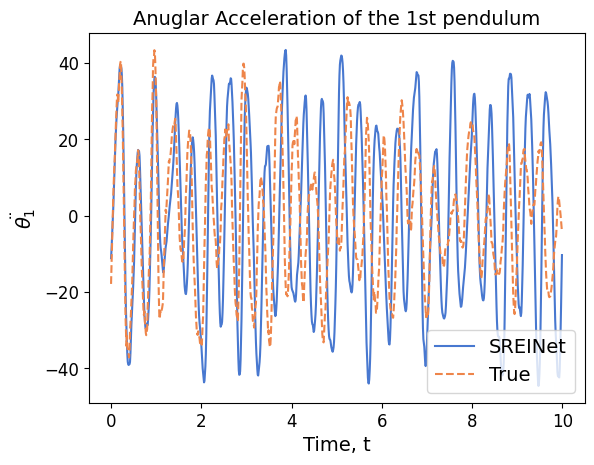

In [24]:
plt.plot(SREINet_pred['t'], pred_dx[4],label='SREINet')
plt.plot(val_t_eval, val_dd_theta[:val_t_eval.shape[0], 1], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\ddot{\theta_1}$')
plt.legend()
plt.title('Anuglar Acceleration of the 1st pendulum')
plt.show()